In [1]:
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random
import helper_utils

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
field_dir = r"G:\Course Contents\ML Projects\Leafsnap\Dataset\leafsnap-dataset\dataset\images\field"

In [5]:
def show_ran_images(dataset, num_images=3,title_prefix="Leaf Species"):
    plt.figure(figsize=(5*num_images,5))

    # Pick random indices
    indices = random.sample(range(len(dataset)), num_images)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{title_prefix}: {dataset.classes[label]}")

    plt.show()

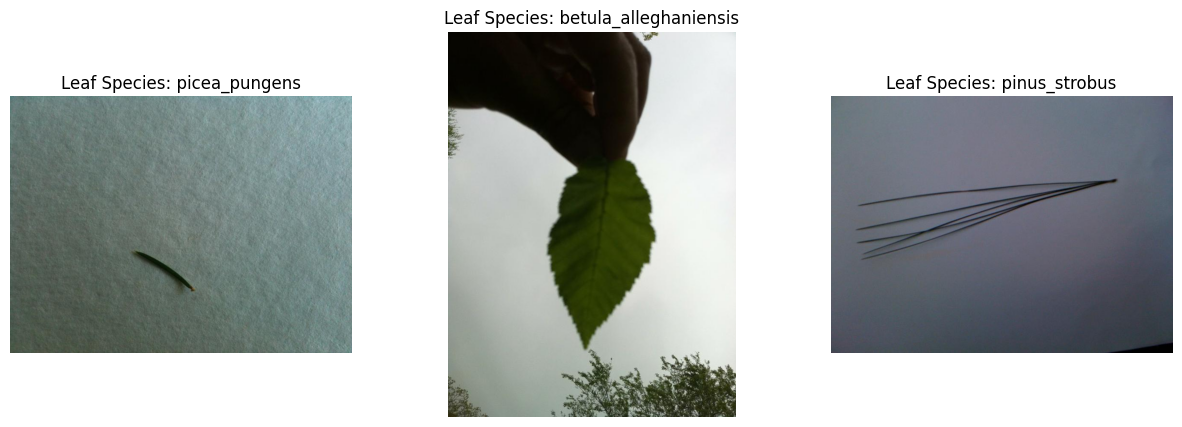

In [6]:
train_dataset_without_transform = datasets.ImageFolder(
    root=field_dir,
    transform=None
)

# Display 3 random images
show_ran_images(train_dataset_without_transform, num_images=3)

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.50),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [8]:
full_dataset= datasets.ImageFolder(root=field_dir, transform=train_transform)

In [9]:
# Split 80% train / 20% val
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset)-train_size

# Randomly splitting the Datasets
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

In [10]:
# Initiaiting DataLoader for Training
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Initiaiting DataLoader for Validating
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [10]:
print("Classes:", full_dataset.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Classes: ['abies_concolor', 'abies_nordmanniana', 'acer_campestre', 'acer_ginnala', 'acer_griseum', 'acer_negundo', 'acer_palmatum', 'acer_pensylvanicum', 'acer_platanoides', 'acer_pseudoplatanus', 'acer_rubrum', 'acer_saccharinum', 'acer_saccharum', 'aesculus_flava', 'aesculus_glabra', 'aesculus_hippocastamon', 'aesculus_pavi', 'ailanthus_altissima', 'albizia_julibrissin', 'amelanchier_arborea', 'amelanchier_canadensis', 'amelanchier_laevis', 'asimina_triloba', 'betula_alleghaniensis', 'betula_jacqemontii', 'betula_lenta', 'betula_nigra', 'betula_populifolia', 'broussonettia_papyrifera', 'carpinus_betulus', 'carpinus_caroliniana', 'carya_cordiformis', 'carya_glabra', 'carya_ovata', 'carya_tomentosa', 'castanea_dentata', 'catalpa_bignonioides', 'catalpa_speciosa', 'cedrus_atlantica', 'cedrus_deodara', 'cedrus_libani', 'celtis_occidentalis', 'celtis_tenuifolia', 'cercidiphyllum_japonicum', 'cercis_canadensis', 'chamaecyparis_pisifera', 'chamaecyparis_thyoides', 'chionanthus_retusus', 'c

In [11]:
class CNNBlock(nn.Module):
    """
    Defines a single convolutional block for a CNN.

    This block consists of a convolutional layer, batch normalization,
    a ReLU activation, and a max-pooling layer, bundled as a sequential module.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        """
        Initializes the layers of the CNNBlock.

        Args:
            in_channels (int): Number of channels in the input image.
            out_channels (int): Number of channels produced by the convolution.
            kernel_size (int, optional): Size of the convolving kernel. Defaults to 3.
            padding (int, optional): Zero-padding added to both sides of the input. Defaults to 1.
        """

        super(CNNBlock, self).__init__()

        # Initialize the parent nn.Module class.
        self.block = nn.Sequential(
            # 2D convolutional layer to apply learnable filters to the input.
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            # Batch normalization to stabilize and accelerate training.
            nn.BatchNorm2d(out_channels),
            # ReLU activation function to introduce non-linearity.
            nn.ReLU(),
            # Max pooling layer to downsample the feature map and reduce spatial dimensions.
            nn.MaxPool2d(kernel_size=2, stride=2)
        ) 

    def forward(self, x):
        """
        Defines the forward pass for the CNNBlock.

        Args:
            x: The input tensor for the block.

        Returns:
            The output tensor after passing through the block.
        """
        
        
        # Pass the input tensor through the sequential block of layers.
       
        return self.block(x)

In [12]:
class SimpleCNN(nn.Module):
    """
    Defines a simple CNN architecture using modular CNNBlocks.

    This model stacks three reusable convolutional blocks followed by a fully
    connected classifier to perform image classification.
    """
    def __init__(self, num_classes):
        """
        Initializes the layers of the SimpleCNN model.

        Args:
            num_classes (int): The number of output classes for the classifier.
        """
        # Initialize the parent nn.Module class.
        super(SimpleCNN, self).__init__()
        
        

        # Define the first convolutional block.
        self.conv_block1 = CNNBlock(in_channels=3, out_channels=32)     # Input RGB images
        # Define the second convolutional block.
        self.conv_block2 = CNNBlock(in_channels=32, out_channels=64)
        # Define the third convolutional block.
        self.conv_block3 = CNNBlock(in_channels=64, out_channels=128)
        # Define the fourth convolutional block.
        self.conv_block4 = CNNBlock(in_channels=128, out_channels=256)

        # Define the fully connected classifier block.
        self.classifier = nn.Sequential(
            # Flatten the 3D feature map (channels, height, width) into a 1D vector.
            nn.Flatten(),
            # First fully connected (linear) layer that maps the flattened features to a hidden layer.
            nn.Linear(256*14*14,512),
            # ReLU activation function to introduce non-linearity.
            nn.ReLU(),
            # Dropout layer to prevent overfitting by randomly setting a fraction of inputs to zero.
            nn.Dropout(0.5),
            # Final fully connected (linear) layer that maps the hidden layer to the output classes.
            nn.Linear(in_features=512, out_features=num_classes)
        ) 
        
        ### END CODE HERE ###

    def forward(self, x):
        """
        Defines the forward pass of the SimpleCNN model.

        Args:
            x (torch.Tensor): The input tensor containing a batch of images.

        Returns:
            torch.Tensor: The output tensor with logits for each class.
        """
        
        
        
        # Pass the input through the first convolutional block.
        x = self.conv_block1(x)
        # Pass the result through the second convolutional block.
        x = self.conv_block2(x)
        # Pass the result through the third convolutional block.
        x = self.conv_block3(x)
        # Pass the result through the fourth convolutional block.
        x = self.conv_block4(x)
        # Pass the final feature map through the classifier.
        x = self.classifier(x)
        
        
        
        # Return the final output tensor.
        return x

In [13]:
# Get the number of classes
num_classes = len(train_dataset.dataset.classes)

# Instantiate the model
model = SimpleCNN(num_classes)

In [14]:
# Loss function
loss_function = nn.CrossEntropyLoss()

# Optimizer for the model with weight_decay
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0005)

In [15]:
def train_epoch(model, train_loader, loss_function, optimizer, device):
    """
    Performs a single training epoch.

    Args:
        model (torch.nn.Module): The neural network model to train.
        train_loader (torch.utils.data.DataLoader): The DataLoader for the training data.
        loss_function (callable): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer.
        device (torch.device): The device (CPU or GPU) to perform training on.

    Returns:
        float: The average training loss for the epoch.
    """
    # Set the model to training mode
    model.train()
    running_loss = 0.0
    # Iterate over batches of data in the training loader
    for images, labels in train_loader:
        # Move images and labels to the specified device
        images, labels = images.to(device), labels.to(device)
        
        
        
        # Clear the gradients of all optimized variables
        optimizer.zero_grad()
        # Perform a forward pass to get model outputs
        outputs = model(images)
        # Calculate the loss
        loss = loss_function(outputs,labels)
        # Perform a backward pass to compute gradients
        loss.backward()
        # Update the model parameters
        optimizer.step()
        
        
        
        # Accumulate the training loss for the batch
        running_loss += loss.item() * images.size(0)
        
    # Calculate and return the average training loss for the epoch
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

In [16]:
def validate_epoch(model, val_loader, loss_function, device):
    """
    Performs a single validation epoch.

    Args:
        model (torch.nn.Module): The neural network model to validate.
        val_loader (torch.utils.data.DataLoader): The DataLoader for the validation data.
        loss_function (callable): The loss function.
        device (torch.device): The device (CPU or GPU) to perform validation on.

    Returns:
        tuple: A tuple containing the average validation loss and validation accuracy.
    """
    # Set the model to evaluation mode
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    
    
    # Disable gradient calculations for validation
    with torch.no_grad():
        
    
    
        # Iterate over batches of data in the validation loader
        for images, labels in val_loader:
            # Move images and labels to the specified device
            images, labels = images.to(device), labels.to(device)
            
           
            
            # Perform a forward pass to get model outputs
            outputs = model(images)
            
            # Calculate the validation loss for the batch
            val_loss = loss_function(outputs,labels)
            # Accumulate the validation loss
            running_val_loss += val_loss.item()
            
            # Get the predicted class labels
            _, predicted = torch.max(outputs,dim=1)
            
            
            
            # Update the total number of samples
            total += labels.size(0)
            # Update the number of correct predictions
            correct += (predicted == labels).sum().item()
            
    # Calculate the average validation loss and accuracy for the epoch
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_accuracy = 100.0 * correct / total
    
    return epoch_val_loss, epoch_accuracy

In [17]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    """
    Trains and validates a PyTorch neural network model.

    Args:
        model (torch.nn.Module): The model to be trained.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training set.
        val_loader (torch.utils.data.DataLoader): DataLoader for the validation set.
        loss_function (callable): The loss function.
        optimizer (torch.optim.Optimizer): The optimization algorithm.
        num_epochs (int): The total number of epochs to train for.
        device (torch.device): The device (e.g., 'cuda' or 'cpu') to run training on.

    Returns:
        tuple: A tuple containing the best trained model and a list of metrics
               (train_losses, val_losses, val_accuracies).
    """
    # Move the model to the specified device (CPU or GPU)
    model.to(device)
    
    # Initialize variables to track the best performing model
    best_val_accuracy = 0.0
    best_model_state = None
    best_epoch = 0
    
    # Initialize lists to store training and validation metrics
    train_losses, val_losses, val_accuracies = [], [], []
    
    print("--- Training Started ---")
    
    # Loop over the specified number of epochs
    for epoch in range(num_epochs):
        # Perform one epoch of training
        epoch_loss = train_epoch(model, train_loader, loss_function, optimizer, device)
        train_losses.append(epoch_loss)
        
        # Perform one epoch of validation
        epoch_val_loss, epoch_accuracy = validate_epoch(model, val_loader, loss_function, device)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_accuracy)
        
        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")
        
        # Check if the current model is the best one so far
        if epoch_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_accuracy
            best_epoch = epoch + 1
            # Save the state of the best model in memory
            best_model_state = copy.deepcopy(model.state_dict())
            
    print("--- Finished Training ---")
    
    # Load the best model weights before returning
    if best_model_state:
        print(f"\n--- Returning best model with {best_val_accuracy:.2f}% validation accuracy, achieved at epoch {best_epoch} ---")
        model.load_state_dict(best_model_state)
    
    # Consolidate all metrics into a single list
    metrics = [train_losses, val_losses, val_accuracies]
    
    # Return the trained model and the collected metrics
    return model, metrics

In [18]:
# Start the training process by calling the training loop function
trained_model, training_metrics = training_loop(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    num_epochs=50, 
    device=device
)



--- Training Started ---
Epoch [1/50], Train Loss: 5.5161, Val Loss: 0.0761, Val Accuracy: 4.86%
Epoch [2/50], Train Loss: 4.7184, Val Loss: 0.0691, Val Accuracy: 8.23%
Epoch [3/50], Train Loss: 4.3719, Val Loss: 0.0627, Val Accuracy: 11.79%
Epoch [4/50], Train Loss: 4.1107, Val Loss: 0.0574, Val Accuracy: 14.31%
Epoch [5/50], Train Loss: 3.8633, Val Loss: 0.0546, Val Accuracy: 19.30%
Epoch [6/50], Train Loss: 3.7072, Val Loss: 0.0500, Val Accuracy: 21.96%
Epoch [7/50], Train Loss: 3.6012, Val Loss: 0.0471, Val Accuracy: 25.78%
Epoch [8/50], Train Loss: 3.4250, Val Loss: 0.0446, Val Accuracy: 27.33%
Epoch [9/50], Train Loss: 3.3430, Val Loss: 0.0436, Val Accuracy: 29.47%
Epoch [10/50], Train Loss: 3.2083, Val Loss: 0.0420, Val Accuracy: 31.28%
Epoch [11/50], Train Loss: 3.1531, Val Loss: 0.0423, Val Accuracy: 31.61%
Epoch [12/50], Train Loss: 3.0619, Val Loss: 0.0376, Val Accuracy: 36.59%
Epoch [13/50], Train Loss: 2.9352, Val Loss: 0.0368, Val Accuracy: 38.67%
Epoch [14/50], Train Los

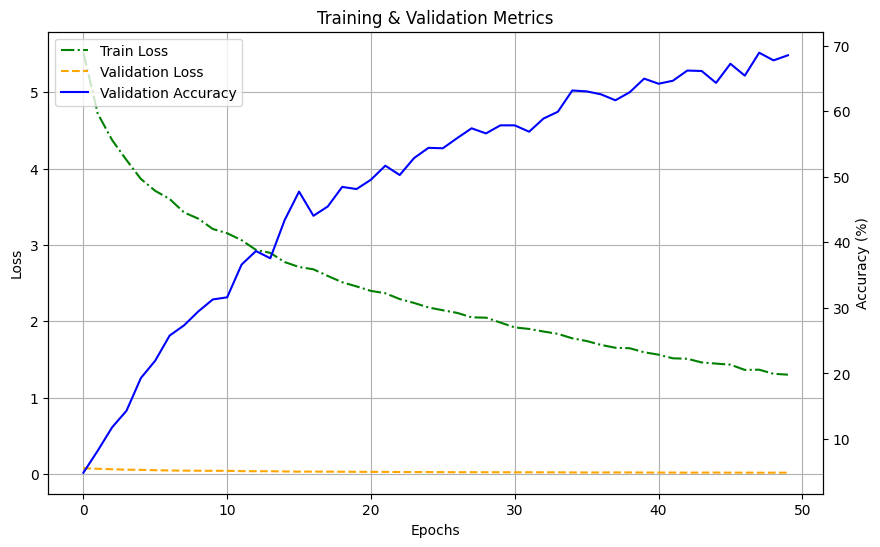

In [23]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot losses on the left y-axis
ax1.plot(train_losses, label='Train Loss', color='green', linestyle='-.')
ax1.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Plot accuracy on the right y-axis
ax2 = ax1.twinx()
ax2.plot(val_accuracies, label='Validation Accuracy', color='blue', linestyle='-')
ax2.set_ylabel('Accuracy (%)')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Training & Validation Metrics')
plt.show()

## Transfer Learning with ResNet18

Our initial attempts with a custom CNN architecture for leaf classification reached a plateau at approximately 68% validation accuracy, despite increasing depth and tuning hyperparameters. This indicates that our model struggles to extract sufficiently rich features from the dataset.

To overcome this limitation, we adopt **transfer learning** using **ResNet18**, a deep residual network pretrained on ImageNet. Transfer learning allows the model to leverage features learned from a large and diverse dataset, providing a strong initialization for our leaf classification task.

Formally, let the pretrained ResNet18 be represented as a function:

$$
f_{\theta_{\text{pretrained}}} : \mathbb{R}^{3 \times 224 \times 224} \to \mathbb{R}^{1000}
$$

We replace the final fully connected layer to match the number of classes $C$ in our leaf dataset:

$$
f_{\theta_{\text{finetune}}}(x) = \text{Linear}(512, C)
$$

where $C = 185$ corresponds to the number of tree species in the Leafsnap Field dataset. This approach allows the network to retain low-level and mid-level features from ImageNet while learning task-specific representations for our classification problem.


In [27]:
train_transformRes = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transformRes = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [28]:
batch_size = 32

train_loaderRes = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

val_loaderRes = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

In [30]:
model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

In [31]:
model.fc = nn.Linear(512, num_classes)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [32]:
optimizerRes = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [33]:
# Start the training process by calling the training loop function
trained_modelRes, training_metricsRes = training_loop(
    model=model, 
    train_loader=train_loaderRes, 
    val_loader=val_loaderRes, 
    loss_function=loss_function, 
    optimizer=optimizerRes, 
    num_epochs=50, 
    device=device
)


--- Training Started ---
Epoch [1/50], Train Loss: 3.2654, Val Loss: 0.0579, Val Accuracy: 64.83%
Epoch [2/50], Train Loss: 1.2801, Val Loss: 0.0360, Val Accuracy: 73.70%
Epoch [3/50], Train Loss: 0.7811, Val Loss: 0.0255, Val Accuracy: 81.80%
Epoch [4/50], Train Loss: 0.5536, Val Loss: 0.0222, Val Accuracy: 82.45%
Epoch [5/50], Train Loss: 0.4408, Val Loss: 0.0188, Val Accuracy: 84.46%
Epoch [6/50], Train Loss: 0.3544, Val Loss: 0.0173, Val Accuracy: 86.08%
Epoch [7/50], Train Loss: 0.3012, Val Loss: 0.0154, Val Accuracy: 87.05%
Epoch [8/50], Train Loss: 0.2626, Val Loss: 0.0152, Val Accuracy: 85.75%
Epoch [9/50], Train Loss: 0.2231, Val Loss: 0.0146, Val Accuracy: 86.20%
Epoch [10/50], Train Loss: 0.2054, Val Loss: 0.0141, Val Accuracy: 87.44%
Epoch [11/50], Train Loss: 0.1851, Val Loss: 0.0128, Val Accuracy: 88.41%
Epoch [12/50], Train Loss: 0.1664, Val Loss: 0.0133, Val Accuracy: 87.18%
Epoch [13/50], Train Loss: 0.1530, Val Loss: 0.0133, Val Accuracy: 85.95%
Epoch [14/50], Train L

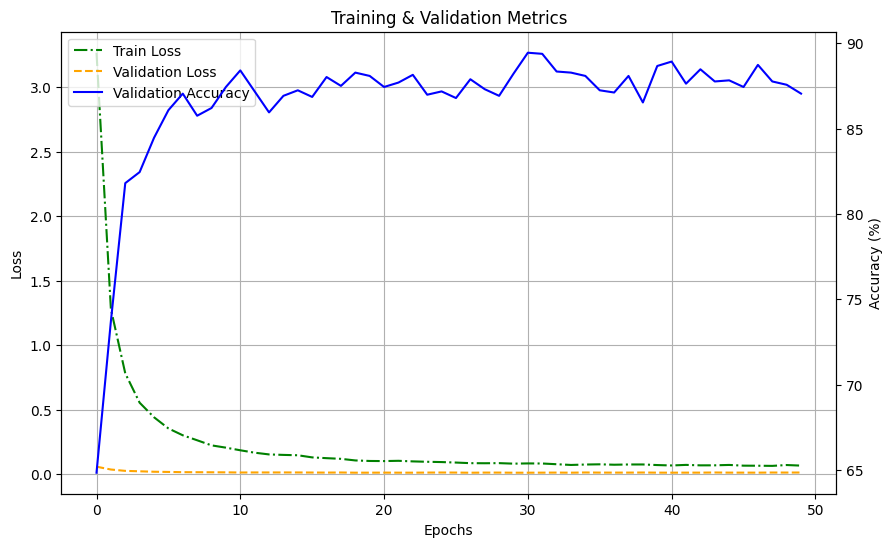

In [35]:
fig, ax1 = plt.subplots(figsize=(10,6))

train_losses, val_losses, val_accuracies = training_metricsRes

# Plot losses on the left y-axis
ax1.plot(train_losses, label='Train Loss', color='green', linestyle='-.')
ax1.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Plot accuracy on the right y-axis
ax2 = ax1.twinx()
ax2.plot(val_accuracies, label='Validation Accuracy', color='blue', linestyle='-')
ax2.set_ylabel('Accuracy (%)')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Training & Validation Metrics')
plt.show()

In [36]:
# Save model weights
torch.save(model.state_dict(), "resnet18_leafsnap.pth")

In [11]:
num_classes = 184  # Leafsnap Field dataset

# Create ResNet18 architecture
model = models.resnet18(weights=None)  # weights=None because we load our own
model.fc = nn.Linear(512, num_classes)

model = model.to(device)

In [12]:
# Load trained parameters
state_dict = torch.load("resnet18_leafsnap.pth", map_location=device)
model.load_state_dict(state_dict)


model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
#Load Class Labels
class_names = train_dataset.dataset.classes

In [14]:
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display


In [15]:
def predict_image(image_bytes):
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

    input_tensor = train_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)

    return image, class_names[predicted.item()]

In [22]:
def on_upload_change(change):
    output.clear_output()

    # ipywidgets FileUpload returns a tuple in newer versions
    uploaded_file = upload.value[0]   # ← FIX IS HERE
    image_bytes = uploaded_file["content"]

    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

    input_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100

    with output:
        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
        plt.show()


In [24]:
upload = widgets.FileUpload(
    accept="image/*",
    multiple=False
)

output = widgets.Output()

upload.observe(on_upload_change, names="value")

display(widgets.VBox([upload, output]))